# Search time vs quality

For each dataset: one panel per metric, search time on the x-axis. Every saved run in `results/<dataset>/<encoder>/*.trec` is scored against `datasets/<dataset>/qrels/<QRELS_SPLIT>.tsv`.

- **Shape** = method (SW, Chamfer, Chamfer symmetric). SW points are colored on a blue gradient by number of slices (see the color bar below the panels); Chamfer is orange, symmetric Chamfer green.
- **Fill** = encoder: ColBERT filled, BERT hollow.

Figures are saved to `results/<dataset>/plots/time_vs_quality.png`. Use the **aws** kernel.

In [1]:
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D

from evaluate import evaluate, load_qrels, load_run
from paths import RESULTS_DIR

DATASETS = None       # e.g. ["arguana", "scidocs"]; None = every dataset in results/
METRICS = ("recall@100", "ndcg@10", "mrr@10")
QRELS_SPLIT = "test"
SAVE = True

/ext3/miniforge3/envs/big_ann/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and score runs

In [2]:
SW_TAG = re.compile(r"sw_L(\d+)_K(\d+)_p(\d+)_s(\d+)")

rows, qrels = [], {}
for path in sorted(RESULTS_DIR.glob("*/*/*.trec")):
    dataset, encoder = path.parent.parent.name, path.parent.name
    if DATASETS and dataset not in DATASETS:
        continue
    if dataset not in qrels:
        try:
            qrels[dataset] = load_qrels(dataset, QRELS_SPLIT)
        except FileNotFoundError:
            print(f"{dataset}: no {QRELS_SPLIT!r} qrels, skipping")
            qrels[dataset] = None
    if qrels[dataset] is None:
        continue

    ranker = path.stem.split("__")[0]
    sw = SW_TAG.fullmatch(ranker)
    meta = path.with_suffix(".meta.json")
    rows.append({
        "dataset": dataset, "encoder": encoder,
        "method": f"SW K={sw[2]} p={sw[3]}" if sw else ranker,
        "slices": int(sw[1]) if sw else np.nan,
        "seconds": json.loads(meta.read_text()).get("seconds", np.nan) if meta.exists() else np.nan,
        **evaluate(load_run(path), qrels[dataset], METRICS),
    })

runs = pd.DataFrame(rows).sort_values(["dataset", "encoder", "method", "slices"], ignore_index=True)

## Plot

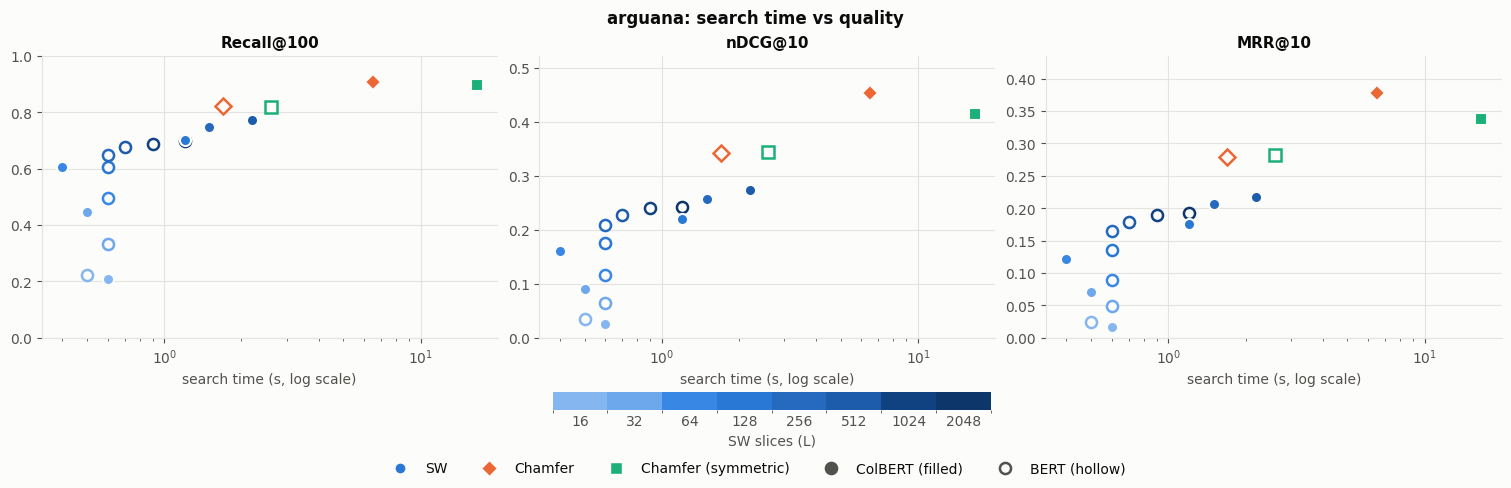

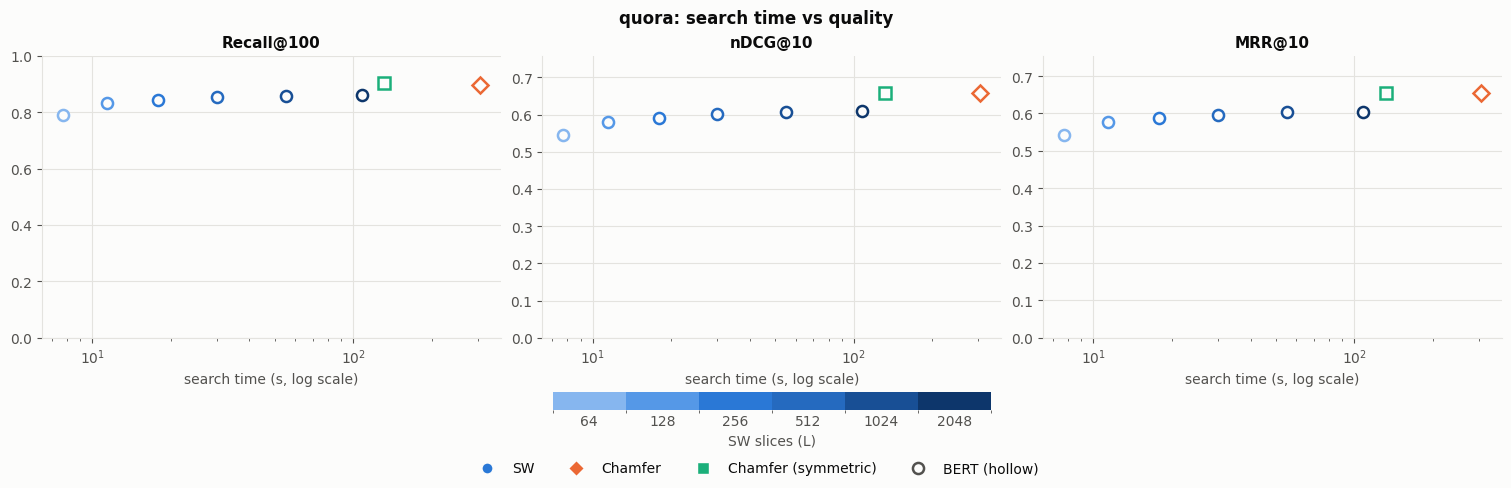

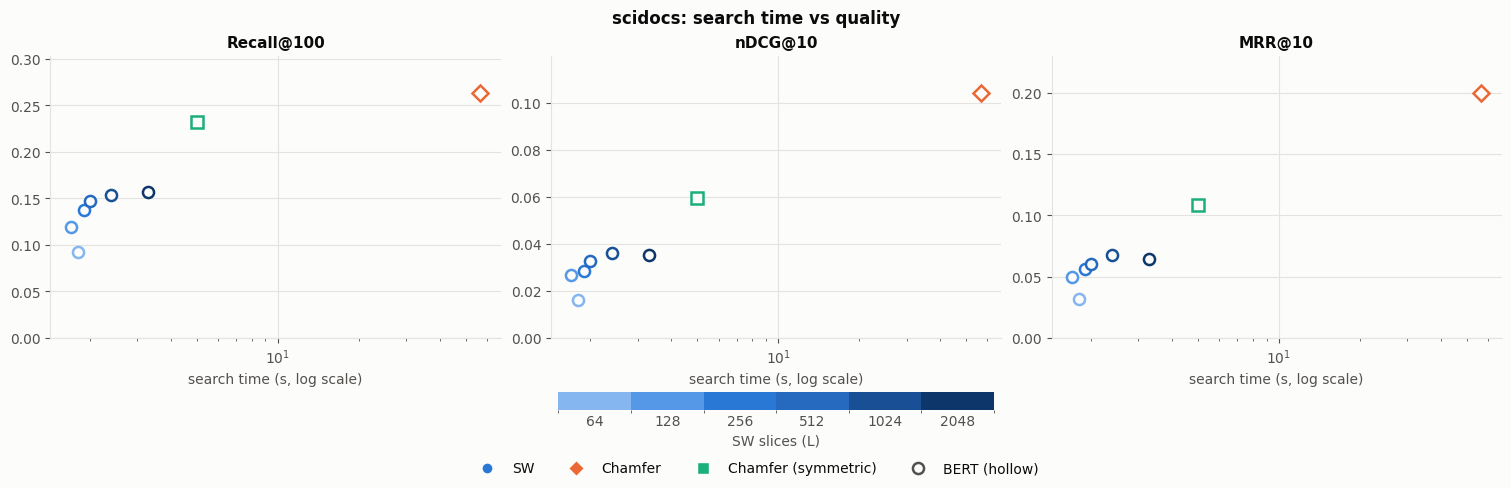

In [3]:
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
# Sequential blue ramp (steps 250 -> 700) for SW slice counts: lighter = fewer slices.
SLICE_RAMP = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6",
              "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
SW_MARKERS = ["o", "^", "v", "P", "X"]   # one shape per SW setting (K, p) if several exist
FIXED = {"chamfer": ("#eb6834", "D", "Chamfer"), "chamfer-sym": ("#1baf7a", "s", "Chamfer (symmetric)")}
ENCODERS = {"colbert": "ColBERT (filled)", "bert": "BERT (hollow)"}
METRIC_NAMES = {"ndcg": "nDCG", "recall": "Recall", "mrr": "MRR", "precision": "Precision"}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "semibold",
})

def slice_colors(slices):
    """Map each distinct slice count to a ramp step, spaced by log2(L)."""
    slices = sorted(slices)
    if len(slices) == 1:
        return {slices[0]: SLICE_RAMP[4]}
    lo, hi = np.log2(slices[0]), np.log2(slices[-1])
    return {L: SLICE_RAMP[round((np.log2(L) - lo) / (hi - lo) * (len(SLICE_RAMP) - 1))] for L in slices}

def draw(ax, x, y, color, marker, filled):
    ax.plot(x, y, ls="none", marker=marker, ms=8, color=color,
            mfc=color if filled else SURFACE, mec=SURFACE if filled else color, mew=1.5 if filled else 1.8)

def plot_dataset(dataset, df):
    df = df.dropna(subset=["seconds"])
    sw_methods = sorted(m for m in df.method.unique() if m.startswith("SW"))
    colors = slice_colors(df.slices.dropna().astype(int).unique())
    fig, axes = plt.subplots(1, len(METRICS), figsize=(5 * len(METRICS), 4.8), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, metric in zip(axes, METRICS):
        for _, r in df.iterrows():
            filled = r.encoder != "bert"
            if r.method in FIXED:
                color, marker, _ = FIXED[r.method]
            else:
                color, marker = colors[int(r.slices)], SW_MARKERS[sw_methods.index(r.method) % len(SW_MARKERS)]
            draw(ax, r.seconds, r[metric], color, marker, filled)
        ax.set_xscale("log")
        ax.set_xlabel("search time (s, log scale)")
        kind, k = metric.split("@")
        ax.set_title(f"{METRIC_NAMES.get(kind, kind)}@{k}")
        ax.set_ylim(0, min(1.0, df[metric].max() * 1.15))

    # Slice gradient: one discrete step per slice count.
    if colors:
        Ls = sorted(colors)
        cmap = ListedColormap([colors[L] for L in Ls])
        norm = BoundaryNorm(np.arange(len(Ls) + 1) - 0.5, len(Ls))
        cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes, location="bottom",
                            ticks=range(len(Ls)), shrink=0.3, aspect=25, pad=0.02)
        cbar.ax.set_xticklabels([str(L) for L in Ls])
        cbar.set_label("SW slices (L)", color=INK_2)
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(length=0, colors=INK_2)

    # Methods (shape; SW color comes from the gradient) and encoders (fill).
    mid = SLICE_RAMP[4]
    handles = [Line2D([], [], ls="none", marker=SW_MARKERS[i % len(SW_MARKERS)], ms=8, color=mid, mec=SURFACE,
                      label="SW" if len(sw_methods) == 1 else m) for i, m in enumerate(sw_methods)]
    handles += [Line2D([], [], ls="none", marker=mk, ms=8, color=c, mec=SURFACE, label=label)
                for m, (c, mk, label) in FIXED.items() if m in set(df.method)]
    handles += [Line2D([], [], ls="none", marker="o", ms=8, color=INK_2, mew=1.8,
                       mfc=SURFACE if e == "bert" else INK_2, mec=INK_2, label=label)
                for e, label in ENCODERS.items() if e in set(df.encoder)]
    fig.legend(handles=handles, loc="outside lower center", ncol=len(handles), frameon=False)
    fig.suptitle(f"{dataset}: search time vs quality", fontweight="semibold", color=INK)
    return fig

for dataset, df in runs.groupby("dataset"):
    fig = plot_dataset(dataset, df)
    if SAVE:
        out = RESULTS_DIR / dataset / "plots"
        out.mkdir(exist_ok=True)
        fig.savefig(out / "time_vs_quality.png", dpi=160)
    plt.show()

## Table

The plotted numbers, one row per run.

In [ ]:
runs.style.format({m: "{:.4f}" for m in METRICS} | {"slices": "{:.0f}", "seconds": "{:.1f}"},
                  na_rep="–").hide(axis="index")